In [1]:
%%capture
%pip install tensorflow-cpu==2.16.2

import os
# Suppress oneDNN optimizations and lower TensorFlow logging level
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
%pip install numpy
%pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np  # Biblioteca para operações numéricas
import tensorflow as tf  # Biblioteca principal para deep learning
from tensorflow.keras.datasets import mnist  # Dataset de dígitos (0–9)
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose  # Camadas da rede
from tensorflow.keras.models import Model  # Classe para criar o modelo
from tensorflow.keras.callbacks import EarlyStopping  # Callback para parar treino automaticamente

# Load the data set  
(x_train, _), (x_test, _) = mnist.load_data()  # Carrega imagens de treino e teste (labels ignorados com _)

# Normalize the pixel values  
x_train = x_train.astype('float32') / 255.  # Converte para float e normaliza (0–255 → 0–1)
x_test = x_test.astype('float32') / 255.  # Mesmo processo para dados de teste

# Expand dimensions to match the input shape (28, 28, 1)  
x_train = np.expand_dims(x_train, axis=-1)  # Adiciona dimensão de canal → (28,28) vira (28,28,1)
x_test = np.expand_dims(x_test, axis=-1)  # Faz o mesmo para teste

# Add noise to the data
noise_factor = 0.5  # Define intensidade do ruído
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)  # Adiciona ruído gaussiano ao treino
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)  # Adiciona ruído ao teste

# Clip the values to be within the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)  # Garante valores entre 0 e 1
x_test_noisy = np.clip(x_test_noisy, 0., 1.)  # Garante valores entre 0 e 1

Build the diffusion model

In [4]:
# Define the diffusion model architecture with reduced complexity
input_layer = Input(shape=(28, 28, 1))  # Define entrada da imagem (28x28 com 1 canal)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)  # Primeira camada convolucional (extrai padrões simples)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # Camada mais profunda (captura padrões mais complexos)

x = Flatten()(x)  # Achata a saída da CNN em um vetor

x = Dense(64, activation='relu')(x)  # Camada totalmente conectada (aprende representação compacta)
x = Dense(28*28*32, activation='relu')(x)  # Expande novamente os dados para reconstrução

x = Reshape((28, 28, 32))(x)  # Reconverte vetor em formato de imagem com múltiplos canais

x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)  # Começa reconstrução (upsampling)
x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)  # Refina reconstrução

output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)  # Saída final (imagem reconstruída)

diffusion_model = Model(input_layer, output_layer)  # Cria o modelo completo

# Compile the model with mixed precision and a different loss function
diffusion_model.compile(optimizer='adam', loss='mean_squared_error')  # Usa MSE para medir erro de reconstrução

# Summary of the optimized model
diffusion_model.summary()  # Mostra arquitetura do modelo

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

Add noise to the data

In [6]:
# Cache and prefetch the data using TensorFlow data pipelines for faster loading
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))  # Cria dataset a partir dos dados (entrada com ruído, saída limpa)

train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # cache → salva em memória | batch(64) → agrupa dados | prefetch → carrega dados antecipadamente

val_dataset = tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))  # Dataset de validação (mesma lógica do treino)

val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Aplica cache, batching e prefetch também na validação

Train the diffusion model

In [7]:
# Implement early stopping based on validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)  
# monitor='val_loss' → acompanha o erro de validação  
# patience=2 → espera 2 épocas sem melhora antes de parar  
# restore_best_weights=True → volta para os melhores pesos encontrados  

# Train the model with early stopping and smaller batch size
diffusion_model.fit(
    train_dataset,  # Dataset de treino (pipeline otimizado)
    epochs=3,  # Número máximo de épocas
    shuffle=True,  # Embaralha os dados
    validation_data=val_dataset,  # Dataset de validação
    callbacks=[early_stopping]  # Aplica early stopping durante o treino
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - loss: 0.0330 - val_loss: 0.0170
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - loss: 0.0130 - val_loss: 0.0130
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - loss: 0.0112 - val_loss: 0.0122


Evaluate the diffusion model

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


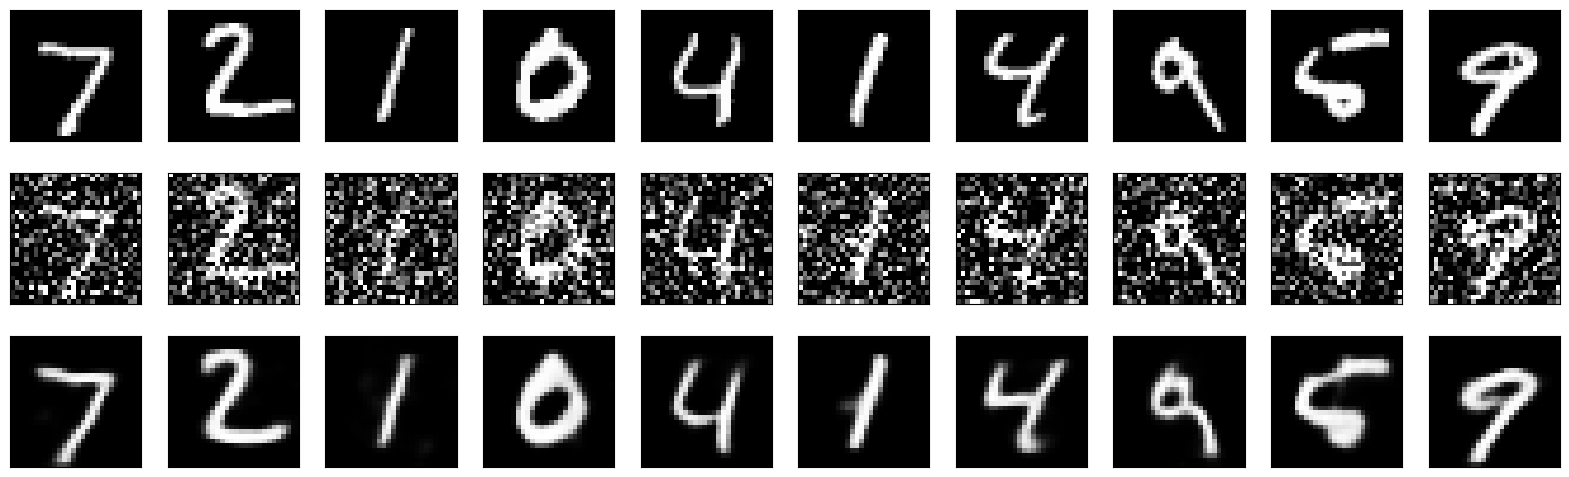

In [9]:
import matplotlib.pyplot as plt  # Biblioteca para visualização de imagens

# Predict the denoised images
denoised_images = diffusion_model.predict(x_test_noisy)  # O modelo recebe imagens com ruído e gera versões "limpas"

# Visualize the results
n = 10  # Number of digits to display (quantidade de imagens a exibir)
plt.figure(figsize=(20, 6))  # Cria uma figura grande para exibição
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)  # Primeira linha: imagens originais
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')  # Mostra imagem original
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

    # Display noisy
    ax = plt.subplot(3, n, i + 1 + n)  # Segunda linha: imagens com ruído
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')  # Mostra imagem ruidosa
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

    # Display denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)  # Terceira linha: imagens reconstruídas (sem ruído)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')  # Mostra imagem limpa pelo modelo
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y
plt.show()  # Exibe todas as imagens

Fine-tune the diffusion model

In [10]:
# Freeze all the layers 
for layer in diffusion_model.layers:
    layer.trainable = False

In [11]:
# Check trainable status of each layer
for i, layer in enumerate(diffusion_model.layers):
    print(f"Layer {i}: {layer.name} — Trainable: {layer.trainable}")

Layer 0: input_layer — Trainable: False
Layer 1: conv2d — Trainable: False
Layer 2: conv2d_1 — Trainable: False
Layer 3: flatten — Trainable: False
Layer 4: dense — Trainable: False
Layer 5: dense_1 — Trainable: False
Layer 6: reshape — Trainable: False
Layer 7: conv2d_transpose — Trainable: False
Layer 8: conv2d_transpose_1 — Trainable: False
Layer 9: conv2d_2 — Trainable: False


In [12]:
# Unfreeze the top layers of the model
for layer in diffusion_model.layers[-4:]:
    layer.trainable = True

# Compile the model again
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model again
diffusion_model.fit(x_train_noisy, x_train,
                    epochs=10,
                    batch_size=64,
                    shuffle=True,
                    validation_data=(x_test_noisy, x_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - loss: 0.0929 - val_loss: 0.0955
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - loss: 0.0922 - val_loss: 0.0951
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - loss: 0.0920 - val_loss: 0.0951
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - loss: 0.0919 - val_loss: 0.0949
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - loss: 0.0918 - val_loss: 0.0949
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0917 - val_loss: 0.0947
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - loss: 0.0916 - val_loss: 0.0947
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0915 - val_loss: 0.0947
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - loss: 0.0915 - val_loss: 0.0947
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0915 - val_loss: 0.0947
